# SVTR-Tiny OCR Training

Notebook for line-level CTC training on the old-books dataset. If an aligned line manifest is not available yet, the notebook builds a bootstrap manifest from page images using horizontal projection line extraction and proportional text splitting.

In [1]:
# Run once if dependencies are missing:
# %pip install torch torchvision albumentations opencv-python-headless python-Levenshtein tqdm matplotlib


In [2]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

try:
    import albumentations as A
except ImportError:
    A = None

from Datasets.Dataclass import (
    DEFAULT_OCR_ALPHABET,
    OCRLineDataset,
    ocr_collate_fn,
)
from prepare_aligned_manifest import build_aligned_manifest
from Train import create_grad_scaler, plot_metrics, train_model, validate_epoch
from ocr_model import build_svtr_tiny_ocr


c:\anacon\envs\cv_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PROJECT_ROOT = Path(r"C:\python\ocr_itmo\OCR_ITMO_2026")
os.chdir(PROJECT_ROOT)

SEED = 42
DATA_ROOT = PROJECT_ROOT / "Datasets"
ALIGNED_LINE_IMAGE_DIR = DATA_ROOT / "lines_aligned"
EASYOCR_CACHE_DIR = DATA_ROOT / "easyocr_cache"
MANIFEST_DIR = DATA_ROOT / "manifests"
FULL_MANIFEST = MANIFEST_DIR / "lines_aligned.tsv"
TRAIN_MANIFEST = MANIFEST_DIR / "train_aligned.tsv"
VAL_MANIFEST = MANIFEST_DIR / "val_aligned.tsv"
FORCE_REBUILD_ALIGNED_MANIFEST = False
EASYOCR_LIMIT_PAGES = None  # Set to a small number, e.g. 5, for a fast smoke test.

IMG_HEIGHT = 32
MAX_WIDTH = 512
MAX_TARGET_LENGTH = 112  # CTC safety margin for W<=512, where max input length is 128.
BATCH_SIZE = 32
NUM_EPOCHS = 30
WARMUP_EPOCHS = 2
LR = 5e-4
WEIGHT_DECAY = 0.05
ACCUMULATION_STEPS = 1  # If OOM on 4 GB VRAM: set BATCH_SIZE=16 and ACCUMULATION_STEPS=2.
NUM_WORKERS = 0  # Keep 0 on Windows/Jupyter. Increase on Linux if needed.
ALPHABET = DEFAULT_OCR_ALPHABET

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti


## Build or Load EasyOCR-Aligned Line Manifest

This step creates `Datasets/manifests/lines_aligned.tsv`: page images are split into line crops, EasyOCR produces rough text for each crop, and Levenshtein alignment maps these rough lines to the page-level groundtruth in reading order. The first run downloads EasyOCR models and can take a while.

In [4]:
if FORCE_REBUILD_ALIGNED_MANIFEST or not FULL_MANIFEST.exists():
    print("Building EasyOCR + Levenshtein aligned manifest...")
    build_aligned_manifest(
        data_root=DATA_ROOT,
        images_folder="300dpi/tiff",
        groundtruth_folder="groundtruth",
        output_manifest=FULL_MANIFEST,
        line_dir=ALIGNED_LINE_IMAGE_DIR,
        cache_dir=EASYOCR_CACHE_DIR,
        alphabet=ALPHABET,
        img_height=IMG_HEIGHT,
        max_width=MAX_WIDTH,
        max_target_length=MAX_TARGET_LENGTH,
        gpu=(device.type == "cuda"),
        limit_pages=EASYOCR_LIMIT_PAGES,
        overwrite_images=False,
        force_ocr=False,
    )
else:
    print("Using existing manifest:", FULL_MANIFEST)

rows = [line for line in FULL_MANIFEST.read_text(encoding="utf-8").splitlines() if line.strip()]
print("Line samples:", len(rows))
print(rows[0] if rows else "No rows found")


Using existing manifest: C:\python\ocr_itmo\OCR_ITMO_2026\Datasets\manifests\lines_aligned.tsv
Line samples: 8088
Datasets/lines_aligned/a013/a013_0000.png	why and wherefore.


In [5]:
def split_manifest(source_path, train_path, val_path, val_size=0.15, seed=42):
    source_path = Path(source_path)
    train_path = Path(train_path)
    val_path = Path(val_path)
    train_path.parent.mkdir(parents=True, exist_ok=True)
    rows = [line for line in source_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    rng = random.Random(seed)
    rng.shuffle(rows)
    n_val = max(1, int(round(len(rows) * val_size)))
    val_rows = rows[:n_val]
    train_rows = rows[n_val:]
    train_path.write_text("\n".join(train_rows) + "\n", encoding="utf-8")
    val_path.write_text("\n".join(val_rows) + "\n", encoding="utf-8")
    return len(train_rows), len(val_rows)

n_train, n_val = split_manifest(FULL_MANIFEST, TRAIN_MANIFEST, VAL_MANIFEST, val_size=0.15, seed=SEED)

print(f"Train lines: {n_train}, val lines: {n_val}")


Train lines: 6875, val lines: 1213


In [6]:
if A is not None:
    train_aug = A.Compose([
        A.Rotate(limit=2, border_mode=cv2.BORDER_CONSTANT, fill=255, p=0.5),
        A.ElasticTransform(alpha=8, sigma=4, p=0.2),
        A.OneOf([
            A.GaussNoise(p=1.0),
            A.Blur(blur_limit=3, p=1.0),
        ], p=0.3),
        A.InvertImg(p=0.05),
    ])
else:
    train_aug = None

train_dataset = OCRLineDataset(
    manifest_path=TRAIN_MANIFEST,
    root_dir=PROJECT_ROOT,
    alphabet=ALPHABET,
    img_height=IMG_HEIGHT,
    max_width=MAX_WIDTH,
    augmentation=train_aug,
    normalize="zero_one",
)
val_dataset = OCRLineDataset(
    manifest_path=VAL_MANIFEST,
    root_dir=PROJECT_ROOT,
    alphabet=ALPHABET,
    img_height=IMG_HEIGHT,
    max_width=MAX_WIDTH,
    augmentation=None,
    normalize="zero_one",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    collate_fn=lambda batch: ocr_collate_fn(batch, pad_value=0.0, max_width=MAX_WIDTH),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
    collate_fn=lambda batch: ocr_collate_fn(batch, pad_value=0.0, max_width=MAX_WIDTH),
)

batch = next(iter(train_loader))
print(batch["images"].shape, batch["targets"].shape, batch["input_lengths"][:5], batch["texts"][0])


torch.Size([32, 1, 32, 512]) torch.Size([1770]) tensor([128, 128, 128, 128, 128]) ancient dwarf said to the king, "of the three


In [7]:
model = build_svtr_tiny_ocr(alphabet=ALPHABET, output_batch_first=True)
criterion = torch.nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

warmup = LinearLR(optimizer, start_factor=0.1, total_iters=max(1, WARMUP_EPOCHS))
cosine = CosineAnnealingLR(
    optimizer,
    T_max=max(1, NUM_EPOCHS - WARMUP_EPOCHS),
    eta_min=1e-6,
)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[max(1, WARMUP_EPOCHS)])
scaler = create_grad_scaler(enabled=True)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params / 1e6:.2f}M")


Trainable parameters: 3.58M


In [8]:
history = train_model(
    model=model,
    num_epochs=NUM_EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    scaler=scaler,
    device=device,
    alphabet=ALPHABET,
    blank_index=0,
    accumulation_steps=ACCUMULATION_STEPS,
    max_grad_norm=1.0,
    use_amp=True,
    best_metric="cer",
    best_mode="min",
    checkpoint_dir="checkpoints_2",
    resume_path=None,
    history_path="training_history_2.json",
)



Epoch 1/30


Saved best checkpoint: cer=1.000000
train_loss=3.78564 val_loss=3.14727 val_cer=1.00000 val_wer=1.00000 val_acc=0.00000 lr=2.75e-04

Epoch 2/30


Saved best checkpoint: cer=0.228165
train_loss=2.45756 val_loss=1.07980 val_cer=0.22817 val_wer=0.55110 val_acc=0.00742 lr=5.00e-04

Epoch 3/30


Saved best checkpoint: cer=0.113996
train_loss=1.09667 val_loss=0.64874 val_cer=0.11400 val_wer=0.28904 val_acc=0.19291 lr=4.98e-04

Epoch 4/30


Saved best checkpoint: cer=0.097290
train_loss=0.85109 val_loss=0.53233 val_cer=0.09729 val_wer=0.23663 val_acc=0.27947 lr=4.94e-04

Epoch 5/30


...

train_loss=0.28358 val_loss=0.38495 val_cer=0.06314 val_wer=0.10789 val_acc=0.58368 lr=2.57e-05

Epoch 27/30


train_loss=0.29617 val_loss=0.38304 val_cer=0.06334 val_wer=0.10929 val_acc=0.58615 lr=1.50e-05

Epoch 28/30


train_loss=0.30082 val_loss=0.38950 val_cer=0.06337 val_wer=0.10876 val_acc=0.58120 lr=7.26e-06

Epoch 29/30


train_loss=0.26880 val_loss=0.38780 val_cer=0.06329 val_wer=0.10798 val_acc=0.58697 lr=2.57e-06

Epoch 30/30


train_loss=0.28548 val_loss=0.38850 val_cer=0.06320 val_wer=0.10806 val_acc=0.58203 lr=1.00e-06


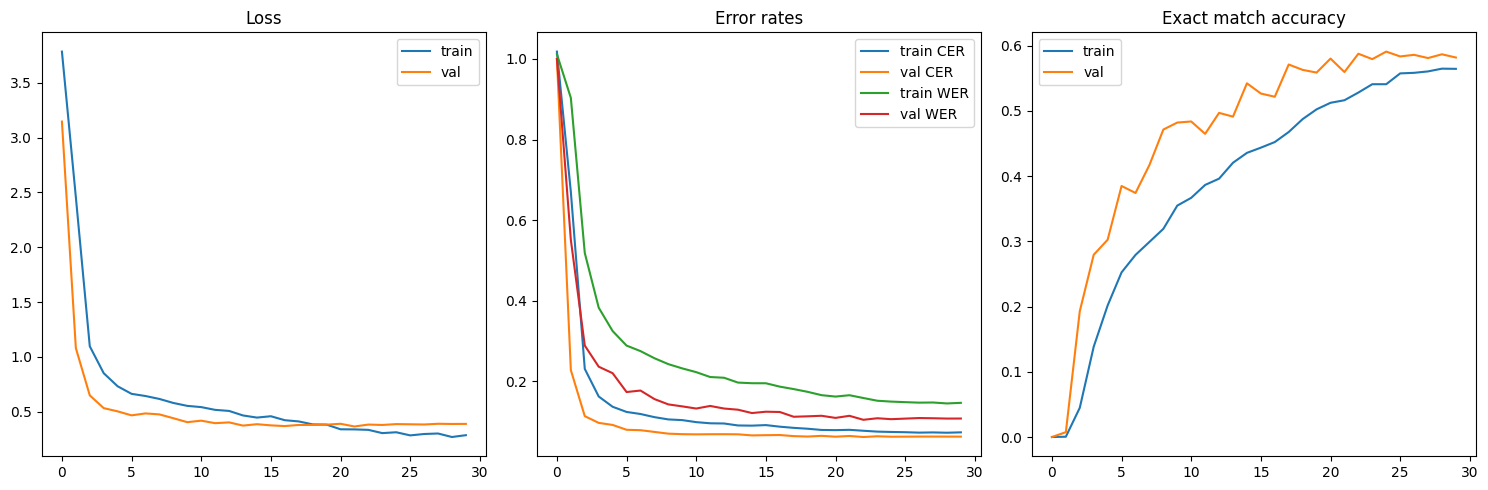

In [9]:
plot_metrics(history)

In [10]:
best_checkpoint = torch.load("checkpoints_2/best_model.pth", map_location=device)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.to(device)
val_loss, val_metrics = validate_epoch(
    model,
    val_loader,
    criterion,
    device=device,
    alphabet=ALPHABET,
    blank_index=0,
    use_amp=True,
)
print("Best checkpoint validation loss:", val_loss)
print("Best checkpoint validation metrics:", val_metrics)

Best checkpoint validation loss: 0.3823093810385156
Best checkpoint validation metrics: {'cer': 0.06224985366934017, 'wer': 0.1049079754601227, 'accuracy': 0.5877988458367683}
